# Visualisation Group Work

You can use this notebook as a template and add your plots in the cells below. We've already added some code to import the necessary packages and included an example plot to show you how a good plot might look like. 

Now it's you your turn to create your first plots with Python's plotting libraries. At the end of this exercise your notebook should contain one plot per library. Since you will share your notebook with the other groups, make sure to add comments so it's easy for them to understand your code. 

Your group number will tell you which kind of plot and data set you should use for the exercise. 

| Group | Plot | Dataset | 
|-------|------|---------|
|  1 | Scatterplot | Seattle Weather |
|  2 | Lineplot | Seattle Weather | 
|  3 | Barchart | Seattle Weather  | 
|  4 | Geographical Maps | Airports  | 
 



## What makes a plot good?

For this exercise the charts do not have to be particularly fancy or provide mind-blowing insights into the data, but they should contain all the elements that make a good plot.
Take the following plot as an example:

![example_plot](image/example_plot.png)

Like the plot above your figures should have/be...
1. ... a meaningful title.
2. ... labels (with units when necessary) on both axis. 
3. ... a legend (if necessary). Make sure it doesn't overlap other important elements.
3. ... text that is easliy readable. You can change and increase the font size, rotate tick labels, flip axis etc. to improve readabilty. 
4. ... not overloaded with information. Try to keep it rather clean and simple.

In [1]:
#Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt

## Import Data
Start by importing the data. We added some lines of code for the groups that work with the seattle weather data to help you get started. Depending on how you name your dataframe, you might have to slightly adjust the code in the cell below.

In [2]:
df_weather = pd.read_csv("data_group_work/seattle-weather.csv")
df_airports = pd.read_csv("data_group_work/airports.csv")


# You might have to adjust the code in this cell if you named your dataframe differently 
# Convert date to datetime format 
df_weather.date = pd.to_datetime(df_weather.date)

# Create new column for year
df_weather['year'] = df_weather.date.dt.year

# Create new column for year-month
df_weather['year_month'] = df_weather['date'].dt.strftime('%Y-%m')
df_weather.head()

,date,precipitation,temp_max,temp_min,wind,weather,year,year_month
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,2012,2012-01
1,2012-01-02,10.9,10.6,2.8,4.5,rain,2012,2012-01
2,2012-01-03,0.8,11.7,7.2,2.3,rain,2012,2012-01
3,2012-01-04,20.3,12.2,5.6,4.7,rain,2012,2012-01
4,2012-01-05,1.3,8.9,2.8,6.1,rain,2012,2012-01


## 1 Matplotlib



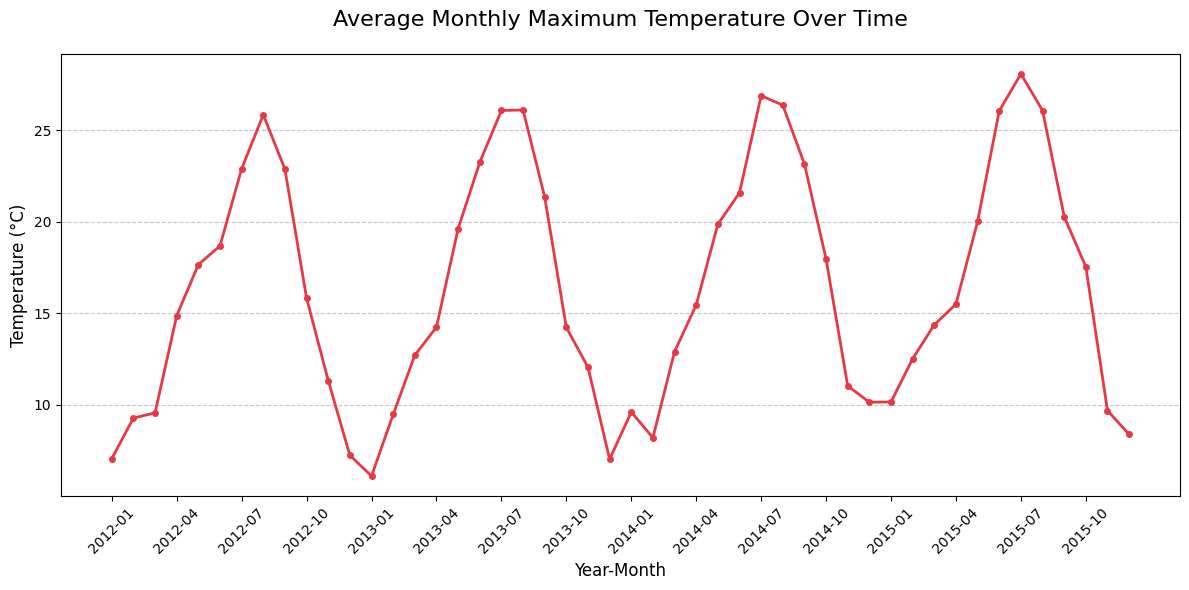

In [3]:
# 1. Prepare the data: Group by the year_month we just created
# We'll take the mean of the weather values for each month
monthly_data = df_weather.groupby('year_month').mean(numeric_only=True)

# 2. Setup the visual style
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-muted') # A soft, professional style

# 3. Plot the data
plt.plot(monthly_data.index, monthly_data['temp_max'],
         marker='o', linestyle='-', color='#e63946', linewidth=2, markersize=4)

# 4. Format the axes
plt.title('Average Monthly Maximum Temperature Over Time', fontsize=16, pad=20)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

# 5. Clean up the X-axis (Dates can get crowded)
# This shows every 6th label so the text doesn't overlap
plt.xticks(monthly_data.index[::3], rotation=45)

# 6. Add finishing touches
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

## 2. Seaborn

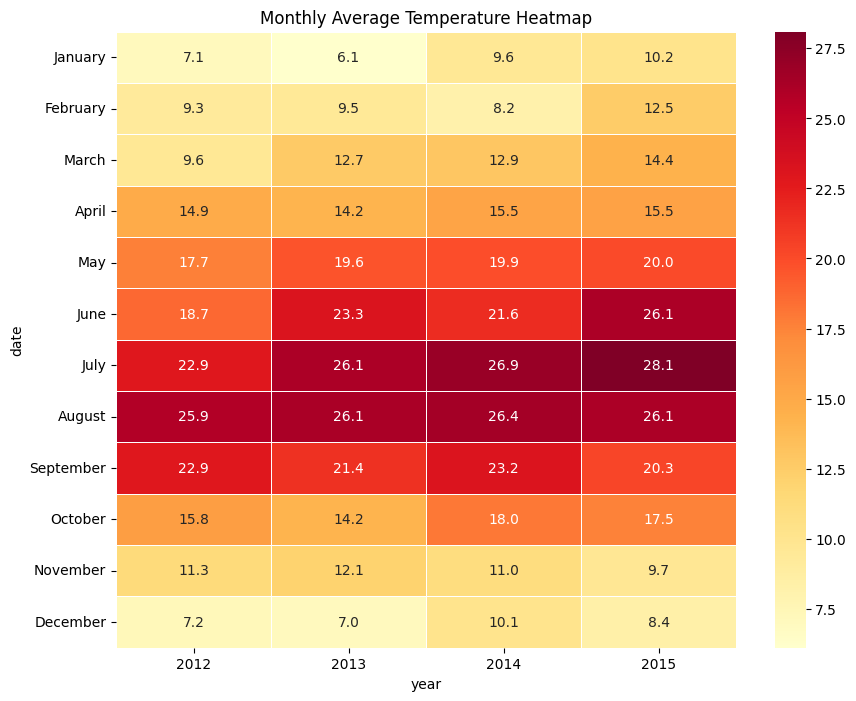

In [4]:
# Create a pivot table of months vs years
weather_pivot = df_weather.pivot_table(
    index=df_weather.date.dt.month_name(), 
    columns='year', 
    values='temp_max', 
    aggfunc='mean'
)

# Reorder months so they aren't alphabetical
months = ["January", "February", "March", "April", "May", "June", 
          "July", "August", "September", "October", "November", "December"]
weather_pivot = weather_pivot.reindex(months)

plt.figure(figsize=(10, 8))
sns.heatmap(weather_pivot, annot=True, fmt=".1f", cmap='YlOrRd', linewidths=.5)

plt.title('Monthly Average Temperature Heatmap')
plt.show()

## 3. Plotly

In [5]:
# Create the interactive line plot
fig = px.line(df_weather, 
              x='date', 
              y='temp_max', 
              title='Daily Max Temperature Over Time',
              labels={'temp_max': 'Max Temp (°C)', 'date': 'Date'},
              template='plotly_white')

# Add a range slider at the bottom for easy navigation
fig.update_xaxes(rangeslider_visible=True)

fig.show()

## 4. Altair

In [6]:
chart = alt.Chart(df_weather).mark_line(color='#457b9d').encode(
    x=alt.X('date:T', title='Date'), # :T tells Altair this is Temporal (time)
    y=alt.Y('temp_max:Q', title='Max Temperature (°C)'), # :Q is Quantitative
    tooltip=['date', 'temp_max', 'precipitation'] # Magic tooltips!
).properties(
    title='Daily Temperature Trends',
    width=700,
    height=400
).interactive() # Enables zooming and panning

chart.show()

alt.Chart(...)